### Imports


In [1]:
import os
import random
import pickle
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.callbacks import TensorBoard, EarlyStopping
from tensorflow.keras.datasets import mnist
from tensorflow.keras.layers import (
    Activation, AlphaDropout, AveragePooling2D, BatchNormalization, Conv2D,
    Conv2DTranspose, Dense, Dropout, Flatten, GaussianNoise,
    GlobalAveragePooling2D, Input, Lambda, Layer, LSTM, MaxPooling2D,
    Permute, Reshape, UpSampling2D, ZeroPadding2D
)
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.utils import to_categorical

from sklearn.model_selection import StratifiedKFold

# For checking device info (GPU availability etc.)
from tensorflow.python.client import device_lib

# Ensure TensorFlow doesn't pre-allocate the entire GPU memory
os.environ['TF_FORCE_GPU_ALLOW_GROWTH'] = 'true'

print(tf.config.list_physical_devices('GPU'))
print(tf.test.is_built_with_cuda())
# print(device_lib.list_local_devices())  # Uncomment if you want detailed device info




[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
True


### Import Dataset

In [4]:
dataset_filename = "RML22.pickle.01A"  # You can change this to any valid file path.

with open(dataset_filename, 'rb') as file:
    Xd = pickle.load(file, encoding='bytes')

### Pre-Process the dataset

In [5]:
# Extract unique modulations (mods) and SNRs from Xd's keys
mods, snrs = map(
    lambda j: sorted(list(set(map(lambda x: x[j], Xd.keys())))),
    [0, 1]
)

# Build up the feature matrix X and label list (mod, snr)
X, lbl = [], []
for mod in mods:
    for snr in snrs:
        X.append(Xd[(mod, snr)])
        lbl.extend([(mod, snr)] * Xd[(mod, snr)].shape[0])

# Combine all data into a single NumPy array
X = np.vstack(X)

# Map each modulation type to an integer
mod_to_int = {mod: i for i, mod in enumerate(mods)}
y = np.array([mod_to_int[mod] for mod, _ in lbl])
Y = to_categorical(y)

# Create stratification labels (mod_snr)
stratify_labels = np.array([f"{mod}_{snr}" for mod, snr in lbl])

# Determine the input shape
in_shp = list(X.shape[1:])
input_shape = (in_shp[0], in_shp[1], 1)

# 2016b classes
classes = [
    'BPSK', 'QPSK', '8PSK', '16QAM', '64QAM',
    'BFSK', 'CPFSK', 'PAM4', 'WBFM', 'AM-DSB'
]

## Used for different year datasets

#classes = ["8PSK", 'AM-DSB','AM-SSB','BPSK',
#           'CPFSK','GFSK','PAM4', 'QAM16',
#           'QAM64','QPSK','WBFM']

#classes = ['OOK', 'ASK4', 'ASK8', 'BPSK', 'QPSK',
#           'PSK8', 'PSK16', 'PSK32', 'APSK16', 
#           'APSK32', 'APSK64', 'APSK128', 'QAM16', 
#           'QAM32', 'QAM64', 'QAM128', 'QAM256',
#           'AM_SSB_WC', 'AM_SSB_SC', 'AM_DSB_WC',
#           'AM_DSB_SC', 'FM', 'GMSK', 'OQPS']

#classes = ['8PSK', 'BPSK', 'CPFSK', 'GFSK', 'PAM4',
#           'AM-DSB', '16QAM', '64QAM', 'QPSK', 'WBFM']


### Construct the Model

In [6]:
def ResNet_Block(x, filters, block_name):
    """
    Builds a small ResNet-like block with two sub-blocks (each having two Conv2D 
    layers and one skip connection).
    
    Parameters:
        x (tf.Tensor): Input tensor.
        filters (int): Number of filters for the Conv2D layers.
        block_name (str): Identifier for naming Conv2D layers.
        
    Returns:
        tf.Tensor: Output tensor after applying the ResNet block.
    """
    # Initial convolution
    x = Conv2D(
        filters, (2, 3), padding='same', kernel_initializer='glorot_uniform',
        data_format="channels_first"
    )(x)
    x = BatchNormalization(axis=3)(x)  # Typically axis=1 if channels_first
    # --------------------------------------------------------------------
    # Sub-block 1
    shortcut = x  # Skip connection
    x = Conv2D(
        filters, (3, 2), padding='same', activation="relu",
        name=f"{block_name}_conv2", kernel_initializer='glorot_uniform',
        data_format="channels_first"
    )(x)
    x = Conv2D(
        filters, (3, 2), padding='same', name=f"{block_name}_conv3",
        kernel_initializer='glorot_uniform', data_format="channels_first"
    )(x)
    x = add([x, shortcut])   # skip connection
    x = Activation("relu")(x)
    # --------------------------------------------------------------------
    # Sub-block 2
    shortcut = x
    x = Conv2D(
        filters, (3, 2), padding='same', activation="relu",
        name=f"{block_name}_conv4", kernel_initializer='glorot_uniform',
        data_format="channels_first"
    )(x)
    x = Conv2D(
        filters, (3, 2), padding='same', name=f"{block_name}_conv5",
        kernel_initializer='glorot_uniform', data_format="channels_first"
    )(x)
    x = BatchNormalization(axis=3)(x)  # Typically axis=1 if channels_first
    x = add([x, shortcut])
    x = Activation("relu")(x)

    return x


def abs_backend(inputs):
    """
    Returns the absolute value of the input tensor.
    
    Parameters:
        inputs (tf.Tensor): Input tensor.
    
    Returns:
        tf.Tensor: Element-wise absolute value of `inputs`.
    """
    return K.abs(inputs)


def expand_dim_backend(inputs):
    """
    Expands the tensor dimensions twice. For example, if the input shape 
    is (batch, height, width), this will become (batch, 1, 1, height, width).
    
    Parameters:
        inputs (tf.Tensor): Input tensor.
    
    Returns:
        tf.Tensor: Tensor with two additional dimensions inserted at axes 1 and 1.
    """
    return K.expand_dims(K.expand_dims(inputs, 1), 1)


def sign_backend(inputs):
    """
    Returns the sign of each element in the input tensor:
      - -1 for negative values
      - 0 for zeros
      - +1 for positive values
    
    Parameters:
        inputs (tf.Tensor): Input tensor.
    
    Returns:
        tf.Tensor: Element-wise sign of `inputs`.
    """
    return K.sign(inputs)


def LC(x):
    """
    A custom function that performs a matrix multiplication with a 
    hard-coded constant `y` of shape (2, 129). It expects `x` to 
    have shape (batch, 80, 18, 129). The steps:
      1. Flatten the last two spatial dimensions (80 * 18) while keeping the 129 dimension.
      2. Dot the flattened tensor with y^T, resulting in shape (batch, 80*18, 2).
      3. Reshape back to (batch, 80, 18, 2).
    
    Parameters:
        x (tf.Tensor): Input tensor, expected shape (batch, 80, 18, 129).
    
    Returns:
        tf.Tensor: Output tensor of shape (batch, 80, 18, 2).
    """
    # Hard-coded constant y of shape (2, 129)
    y = K.constant([[0]*129, [1]*129], dtype='float32')
    
    # Flatten x from (batch, 80, 18, 129) to (batch, 80*18, 129)
    x_flattened = K.reshape(x, shape=(-1, 80*18, 129))
    
    # Multiply by y^T (129 x 2) => result is (batch, 80*18, 2)
    x_transformed = K.dot(x_flattened, K.transpose(y))
    
    # Reshape to (batch, 80, 18, 2)
    result_shape = (-1, 80, 18, 2)
    return K.reshape(x_transformed, result_shape)


In [7]:
def abs_backend(inputs):
    """
    Returns the absolute value of the input tensor.
    
    Parameters:
        inputs (tf.Tensor): Input tensor.
    
    Returns:
        tf.Tensor: Element-wise absolute value of `inputs`.
    """
    return K.abs(inputs)


def expand_dim_backend(inputs):
    """
    Expands the tensor dimensions twice. For example, if the input shape 
    is (batch, height, width), this will become (batch, 1, 1, height, width).
    
    Parameters:
        inputs (tf.Tensor): Input tensor.
    
    Returns:
        tf.Tensor: Tensor with two additional dimensions inserted at axes 1 and 1.
    """
    return K.expand_dims(K.expand_dims(inputs, 1), 1)


def sign_backend(inputs):
    """
    Returns the sign of each element in the input tensor:
      - -1 for negative values
      - 0 for zeros
      - +1 for positive values
    
    Parameters:
        inputs (tf.Tensor): Input tensor.
    
    Returns:
        tf.Tensor: Element-wise sign of `inputs`.
    """
    return K.sign(inputs)


def LC(x):
    """
    A custom function that performs a matrix multiplication with a 
    hard-coded constant `y` of shape (2, 129). It expects `x` to 
    have shape (batch, 80, 18, 129). The steps:
      1. Flatten the last two spatial dimensions (80 * 18) while keeping the 129 dimension.
      2. Dot the flattened tensor with y^T, resulting in shape (batch, 80*18, 2).
      3. Reshape back to (batch, 80, 18, 2).
    
    Parameters:
        x (tf.Tensor): Input tensor, expected shape (batch, 80, 18, 129).
    
    Returns:
        tf.Tensor: Output tensor of shape (batch, 80, 18, 2).
    """
    # Hard-coded constant y of shape (2, 129)
    y = K.constant([[0]*129, [1]*129], dtype='float32')
    
    # Flatten x from (batch, 80, 18, 129) to (batch, 80*18, 129)
    x_flattened = K.reshape(x, shape=(-1, 80*18, 129))
    
    # Multiply by y^T (129 x 2) => result is (batch, 80*18, 2)
    x_transformed = K.dot(x_flattened, K.transpose(y))
    
    # Reshape to (batch, 80, 18, 2)
    result_shape = (-1, 80, 18, 2)
    return K.reshape(x_transformed, result_shape)

### TAD Denoiser

In [8]:
#TAD denoiser
def auto_coder_denoise(input_tensor, per):
    """
    The TAD denoiser is an autoencoder-like architecture that attempts
    to denoise its input via thresholding in the feature domain.

    Args:
        input_tensor (tf.Tensor): Input feature map, e.g., shape 
            (batch, height, width, channels) or (batch, channels, height, width).
        per (float): A hyperparameter used to scale the computed thresholds.

    Returns:
        tf.Tensor: The denoised output tensor.
    """
    # Save the original identity if needed for residuals (not directly used here)
    identity = input_tensor
    
    # -------------------------------------------------------
    # ENCODER
    # -------------------------------------------------------
    # 1) Batch Normalization
    x = BatchNormalization()(input_tensor)
    
    # 2) Convolution layers
    x = Conv2D(
        filters=64, kernel_size=(2, 3), strides=1, padding='same',
        kernel_initializer=glorot_uniform(), activation='relu'
    )(x)
    x = Conv2D(
        filters=16, kernel_size=(2, 3), strides=1, padding='same',
        kernel_initializer=glorot_uniform()
    )(x)
    
    # -------------------------------------------------------
    # Threshold Computation
    # -------------------------------------------------------
    # 3) Compute absolute value and global mean
    residual_abs = Lambda(abs_backend)(x)
    abs_mean = GlobalAveragePooling2D()(residual_abs)
    
    # 4) Compute scaling coefficients (two Dense layers)
    scales = Dense(
        16, activation=None,
        kernel_initializer=he_normal(),
        kernel_regularizer=l2(1e-4)
    )(abs_mean)
    scales = BatchNormalization()(scales)
    scales = Activation('relu')(scales)
    scales = Dense(
        16, activation='sigmoid',
        kernel_regularizer=l2(1e-4)
    )(scales)
    
    # 5) Expand dims so we can multiply across spatial dimensions
    #    The expand_dim_backend is expected to insert extra dimensions 
    #    to match the shape of 'x'
    scales = Lambda(expand_dim_backend)(scales)
    
    # 6) Calculate thresholds
    #    threshold = (abs_mean * scales) + per*(abs_mean * scales)
    #    effectively = abs_mean * scales * (1 + per)
    thres = multiply([abs_mean, scales]) + \
            (per * multiply([abs_mean, scales]))
    
    # -------------------------------------------------------
    # Denoising
    # -------------------------------------------------------
    # 7) Soft-thresholding: residual_abs - threshold
    sub = subtract([residual_abs, thres])
    zeros = subtract([sub, sub])  # effectively an array of zeros with same shape
    n_sub = maximum([sub, zeros]) # ReLU(sub) => max(sub, 0)
    
    # 8) Reintroduce the sign of the original activation
    residual = multiply([
        Lambda(sign_backend)(x),
        n_sub
    ])
    
    # -------------------------------------------------------
    # DECODER
    # -------------------------------------------------------
    # 9) Decode back to original channel dimensions
    d = Conv2D(
        filters=16, kernel_size=(2, 3), strides=1, padding='same',
        kernel_initializer=glorot_uniform(), activation='relu'
    )(residual)
    d = Conv2D(
        filters=64, kernel_size=(2, 3), strides=1, padding='same',
        kernel_initializer=glorot_uniform()
    )(d)
    output = Conv2D(
        filters=1, kernel_size=(2, 3), strides=1, padding='same',
        kernel_initializer=glorot_uniform()
    )(d)
    
    return output

In [9]:
import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.layers import (
    Layer, BatchNormalization, Conv2D, GlobalAveragePooling2D,
    Dense, Activation, Lambda, multiply, subtract, maximum
)
from tensorflow.keras.regularizers import l2
from tensorflow.keras.initializers import glorot_uniform, he_normal

# -----------------------------------------------------------------
# Helper Functions (for Lambda layers)
# -----------------------------------------------------------------
def abs_backend(inputs):
    """
    Returns element-wise absolute value of 'inputs'.
    """
    return tf.abs(inputs)

def expand_dim_backend(inputs):
    """
    Expands the tensor dimensions twice. 
    E.g., (batch, channels) -> (batch, 1, 1, channels).
    """
    return tf.expand_dims(tf.expand_dims(inputs, 1), 1)

def sign_backend(inputs):
    """
    Returns the sign of each element:
      - -1 for negative values
      -  0 for zeros
      - +1 for positive values
    """
    return tf.sign(inputs)


# -----------------------------------------------------------------
# Main Denoising Layer
# -----------------------------------------------------------------
class AutoEncoderDenoise(Layer):
    """
    A custom Keras layer implementing the TAD denoiser autoencoder:
      - Encoder Phase: 
          1) Batch norm
          2) Two convolution layers
          3) Compute absolute value and average pooling
          4) Dense layers to generate threshold scaling factors
      - Thresholding/Denoising:
          1) Compute thresholds
          2) Subtract and clamp negative values
          3) Multiply by sign of original conv output
      - Decoder Phase:
          1) Two more convolution layers
          2) Final 1-channel convolution as output
    """

    def __init__(self, per, **kwargs):
        """
        Args:
            per (float): The threshold scaling factor (multiplier).
        """
        super(AutoEncoderDenoise, self).__init__(**kwargs)
        self.per = per

        # ---------------------------------------------------------
        # ENCODER
        # ---------------------------------------------------------
        self.batch_norm1 = BatchNormalization()
        
        self.conv1 = Conv2D(
            filters=64, kernel_size=(2, 3), strides=1, padding='same',
            kernel_initializer=glorot_uniform(), activation='relu'
        )
        self.conv2 = Conv2D(
            filters=16, kernel_size=(2, 3), strides=1, padding='same',
            kernel_initializer=glorot_uniform()
        )
        
        # Calculate absolute value and mean
        self.lambda_abs = Lambda(abs_backend)
        self.global_avg_pool = GlobalAveragePooling2D()
        
        # Compute scaling coefficients
        self.dense1 = Dense(
            16, activation=None, kernel_initializer=he_normal(),
            kernel_regularizer=l2(1e-4)
        )
        self.batch_norm2 = BatchNormalization()
        self.activation_relu = Activation('relu')
        self.dense2 = Dense(
            16, activation='sigmoid',
            kernel_regularizer=l2(1e-4)
        )
        self.lambda_expand = Lambda(expand_dim_backend)
        
        self.lambda_sign = Lambda(sign_backend)

        # ---------------------------------------------------------
        # DECODER
        # ---------------------------------------------------------
        self.conv3 = Conv2D(
            filters=16, kernel_size=(2, 3), strides=1, padding='same',
            kernel_initializer=glorot_uniform(), activation='relu'
        )
        self.conv4 = Conv2D(
            filters=64, kernel_size=(2, 3), strides=1, padding='same',
            kernel_initializer=glorot_uniform()
        )
        self.conv5 = Conv2D(
            filters=1, kernel_size=(2, 3), strides=1, padding='same',
            kernel_initializer=glorot_uniform()
        )

    def call(self, inputs, **kwargs):
        """
        Forward pass of the TAD autoencoder.
        
        Args:
            inputs (tf.Tensor): Tensor of shape 
                (batch_size, height, width, channels)
                or (batch_size, channels, height, width) if channels_first.
        
        Returns:
            tf.Tensor: Denoised output of shape matching the input spatial dims
                       with 1 output channel.
        """
        # ---------------------------------------------------------
        # ENCODER
        # ---------------------------------------------------------
        x = self.batch_norm1(inputs)
        x = self.conv1(x)
        x = self.conv2(x)
        
        # Compute absolute value and global average
        residual_abs = self.lambda_abs(x)
        abs_mean = self.global_avg_pool(residual_abs)
        
        # ---------------------------------------------------------
        # SCALING COEFFICIENTS & THRESHOLD
        # ---------------------------------------------------------
        scales = self.dense1(abs_mean)
        scales = self.batch_norm2(scales)
        scales = self.activation_relu(scales)
        scales = self.dense2(scales)
        scales = self.lambda_expand(scales)
        
        # threshold = abs_mean * scales + per * (abs_mean * scales)
        # effectively abs_mean * scales * (1 + per)
        thres = multiply([abs_mean, scales]) + \
                (self.per * multiply([abs_mean, scales]))
        
        # ---------------------------------------------------------
        # DENOISING OPERATION (Soft-Thresholding)
        # ---------------------------------------------------------
        sub_output = subtract([residual_abs, thres])
        zeros_tensor = subtract([sub_output, sub_output])  # same shape zero
        n_sub = maximum([sub_output, zeros_tensor])
        residual = multiply([self.lambda_sign(x), n_sub])
        
        # ---------------------------------------------------------
        # DECODER
        # ---------------------------------------------------------
        x = self.conv3(residual)
        x = self.conv4(x)
        x = self.conv5(x)
        
        return x

    def get_config(self):
        """
        Required method when extending tf.keras.layers.Layer so the 
        custom layer can be serialized.
        """
        config = super().get_config()
        config.update({"per": self.per})
        return config

In [10]:
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.layers import Layer

# --------------------------------------------------------------------
# Load an existing SNR predictor model
# --------------------------------------------------------------------
snr_predictor = load_model('best_model_fold_0.h5')

# Display the model summary and output shape
snr_predictor.summary()
print("SNR Predictor Output Shape:", snr_predictor.output_shape)

# --------------------------------------------------------------------
# Conditional Denoising Layer
# --------------------------------------------------------------------
class ConditionalDenoisingLayer(Layer):
    """
    A custom layer that conditionally applies a denoising layer based on
    the predicted SNR (Signal-to-Noise Ratio).

    If the predicted SNR is below a certain threshold, it applies the
    denoising autoencoder; otherwise, it simply returns the original
    inputs ("bypasses" the denoising).

    Attributes:
        snr_model (tf.keras.Model): A pre-trained model that predicts the
            SNR from flattened input.
        denoise_layer (tf.keras.layers.Layer): The denoising layer (or 
            sub-model) to be applied when SNR < threshold.
        threshold (float): The SNR threshold below which denoising is
            applied.
    """
    def __init__(self, snr_model, denoise_layer, threshold=5.0, **kwargs):
        """
        Initializes the ConditionalDenoisingLayer.

        Args:
            snr_model (tf.keras.Model): Pre-trained model that takes in
                flattened input and outputs a single SNR value per sample.
            denoise_layer (tf.keras.layers.Layer): The denoising layer
                (autoencoder) to apply if SNR < threshold.
            threshold (float, optional): SNR threshold. Defaults to 5.0.
        """
        super(ConditionalDenoisingLayer, self).__init__(**kwargs)
        self.snr_model = snr_model
        self.denoise_layer = denoise_layer
        self.threshold = threshold

    def call(self, inputs, **kwargs):
        """
        Forward pass:
          1. Flatten the input to shape (batch, 256) for SNR prediction.
          2. Compute SNR using the pre-trained model and squeeze to shape (batch,).
          3. If SNR < threshold, apply denoising; otherwise bypass.

        Args:
            inputs (tf.Tensor): Input data, e.g. shape (batch, height, width, channels).
        
        Returns:
            tf.Tensor: Either the denoised tensor or the original tensor, 
                       depending on the predicted SNR.
        """
        # Reshape inputs to match what the SNR model expects: (batch_size, 256)
        flat_inputs = tf.reshape(inputs, (-1, 256))

        # Predict SNR (shape: (batch_size, 1)), then remove trailing dim
        snr_values = tf.squeeze(self.snr_model(flat_inputs), axis=-1)  # shape: (batch,)

        # Define the "apply_autoencoder" and "bypass" branches.
        def apply_autoencoder():
            return self.denoise_layer(inputs)  # denoise path

        def bypass():
            return inputs  # pass-through path

        # tf.less(snr_values, threshold) => boolean mask, shape: (batch,)
        # We expand dims to broadcast it over (height, width, channels).
        condition = tf.less(snr_values, self.threshold)
        condition = condition[:, tf.newaxis, tf.newaxis, tf.newaxis]  # shape: (batch, 1, 1, 1)

        # Use tf.where to select between denoised or original inputs
        return tf.where(condition, apply_autoencoder(), bypass())

    def compute_output_shape(self, input_shape):
        """
        Describes the output shape of this layer (same as input shape).
        """
        return input_shape


Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 256)]             0         
                                                                 
 dense (Dense)               (None, 128)               32896     
                                                                 
 dropout (Dropout)           (None, 128)               0         
                                                                 
 dense_1 (Dense)             (None, 64)                8256      
                                                                 
 dropout_1 (Dropout)         (None, 64)                0         
                                                                 
 dense_2 (Dense)             (None, 1)                 65        
                                                                 
Total params: 41,217
Trainable params: 41,217
Non-trainable p

In [11]:
print(len(classes))
# Usage in a model

inputs = Input(shape=(2, 128, 1))

denoiser = AutoEncoderDenoise(per=1)
conditional_layer = ConditionalDenoisingLayer(snr_predictor, denoiser, threshold=5)

model_inputs = conditional_layer(inputs)

# Ensure the reshape matches the expected dimensionality for ZeroPadding2D
model_inputs = Reshape([1] + in_shp)(model_inputs)  # This should result in a shape compatible with channels_first

model_inputs = ZeroPadding2D((1,2), data_format='channels_first')(model_inputs)
model_inputs = Conv2D(80, (2,3), padding='valid', activation='relu', name="conv1", kernel_initializer='glorot_uniform', data_format='channels_first')(model_inputs)
model_inputs = Permute((1,3,2))(model_inputs)
model_inputs = Activation('relu')(model_inputs)



model_inputs = ResNet_Block(model_inputs ,32, "Block1")  #shape:(1,512,32)
model_inputs = MaxPooling2D(pool_size=(1, 1), strides=(2, 1), padding='valid', data_format="channels_first")(model_inputs)
model_inputs = ResNet_Block(model_inputs,32,"Block2")
model_inputs = MaxPooling2D(pool_size=(1, 1), strides=(2, 1), padding='valid', data_format="channels_first")(model_inputs)
model_inputs = ResNet_Block(model_inputs,32,"Block3")
model_inputs = Flatten()(model_inputs)

model_inputs = Dense(128, activation='selu', kernel_initializer='he_normal', name="dense1")(model_inputs)
# Full Con 2
model_inputs = Dense(128, activation='selu', kernel_initializer='he_normal', name="dense2")(model_inputs)
model_inputs = AlphaDropout(0.2)(model_inputs)
# Full Con 3
model_inputs = Dense(len(classes), kernel_initializer='he_normal', name="dense3")(model_inputs)
# SoftMax
model_inputs = Activation('softmax')(model_inputs)
model_proposal = Model(inputs=inputs, outputs=model_inputs)

adam = optimizers.Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999, epsilon=1e-08)

model_proposal.compile(loss='categorical_crossentropy', optimizer=adam, metrics=['accuracy'])
model_proposal.summary()


10
Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 2, 128, 1)]  0           []                               
                                                                                                  
 conditional_denoising_layer (C  (None, 2, 128, 1)   56582       ['input_1[0][0]']                
 onditionalDenoisingLayer)                                                                        
                                                                                                  
 reshape (Reshape)              (None, 1, 2, 128)    0           ['conditional_denoising_layer[0][
                                                                 0]']                             
                                                                                           

### KFolds 

In [12]:
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

snr_accuracies = {snr: [] for snr in np.unique(snrs)}

# Assuming snrs is an array of SNR values corresponding to each sample in X
# This needs to be defined based on your dataset structure
snrs = np.array([snr for _, snr in lbl])

# Initialize a dictionary to hold scores for each SNR level, for each fold
snr_scores = {snr: [] for snr in np.unique(snrs)}

print(stratify_labels)

X = np.array(X)  # If X was a tensor
stratify_labels = np.array(stratify_labels)  # If stratify_labels was a tensor or list

# Now let's ensure that 'X' and 'stratify_labels' are both NumPy arrays
assert isinstance(X, np.ndarray)
assert isinstance(stratify_labels, np.ndarray)


data_to_save = []
for fold, (train_idx, test_idx) in enumerate(skf.split(X, stratify_labels)):
    print(f"Training on fold {fold+1}/{n_splits}...")
    X_train, X_test = X[train_idx], X[test_idx]
    Y_train, Y_test = Y[train_idx], Y[test_idx]
    snrs_test = snrs[test_idx]  # Extract SNR values for the test set

    # Train the model
    history = model_proposal.fit(X_train, Y_train,
                                 batch_size=1024,
                                 epochs=500,
                                 verbose=2,
                                 validation_data=(X_test, Y_test),
                                 callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=20, verbose=1, mode='auto')])
    
    # Evaluate the model
    score = model_proposal.evaluate(X_test, Y_test, verbose=0)
    print(f"Fold {fold+1} - Loss: {score[0]}, Accuracy: {score[1]}")
    
    # Aggregate accuracies by SNR
    unique_snrs_test = np.unique(snrs_test)
    
    # Ensure the model is evaluated for each SNR level
    for snr in np.unique(snrs_test):
        snr_mask = snrs_test == snr
        X_test_snr = X_test[snr_mask]
        Y_test_snr = Y_test[snr_mask]

        # Evaluate the model for the specific SNR segment of the test data
        snr_accuracy = model_proposal.evaluate(X_test_snr, Y_test_snr, verbose=0)[1]  # Obtain accuracy

        # Store the accuracy for the current SNR level
        snr_accuracies[snr].append(snr_accuracy)

# Now 'snr_scores' holds lists of accuracies for each unique SNR across folds



['8PSK_-20' '8PSK_-20' '8PSK_-20' ... 'WBFM_20' 'WBFM_20' 'WBFM_20']
Training on fold 1/5...
Epoch 1/500
329/329 - 50s - loss: 2.3723 - accuracy: 0.1008 - val_loss: 2.3673 - val_accuracy: 0.1000 - 50s/epoch - 153ms/step
Epoch 2/500
329/329 - 45s - loss: 2.3044 - accuracy: 0.1041 - val_loss: 2.3056 - val_accuracy: 0.1084 - 45s/epoch - 135ms/step
Epoch 3/500
329/329 - 44s - loss: 2.3038 - accuracy: 0.1050 - val_loss: 2.3045 - val_accuracy: 0.1058 - 44s/epoch - 135ms/step
Epoch 4/500
329/329 - 44s - loss: 2.2211 - accuracy: 0.1385 - val_loss: 13.9610 - val_accuracy: 0.0956 - 44s/epoch - 135ms/step
Epoch 5/500
329/329 - 46s - loss: 2.0058 - accuracy: 0.2213 - val_loss: 5.7639 - val_accuracy: 0.1542 - 46s/epoch - 139ms/step
Epoch 6/500
329/329 - 45s - loss: 1.9552 - accuracy: 0.2473 - val_loss: 2.6483 - val_accuracy: 0.1763 - 45s/epoch - 138ms/step
Epoch 7/500
329/329 - 45s - loss: 1.8905 - accuracy: 0.2590 - val_loss: 2.9172 - val_accuracy: 0.2213 - 45s/epoch - 136ms/step
Epoch 8/500
329/3

### Plotting Results

In [37]:
import numpy as np
import tensorflow as tf
from sklearn.model_selection import StratifiedKFold

# Number of splits for cross-validation
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

# Dictionary for accuracies by SNR (computed per fold)
snr_accuracies = {snr: [] for snr in np.unique(snrs)}

# Assuming 'snrs' is an array of SNR values corresponding to each sample in X,
# e.g., derived from 'lbl' where each element is (mod, snr).
snrs = np.array([snr for _, snr in lbl])

# Initialize a dictionary to hold scores for each SNR level, for each fold
# (Not actively updated in this snippet, but preserved to maintain your original logic)
snr_scores = {snr: [] for snr in np.unique(snrs)}

print(stratify_labels)

# Convert X and stratify_labels to NumPy arrays if they aren't already
X = np.array(X)  
stratify_labels = np.array(stratify_labels)

# Sanity checks
assert isinstance(X, np.ndarray)
assert isinstance(stratify_labels, np.ndarray)

data_to_save = []
for fold, (train_idx, test_idx) in enumerate(skf.split(X, stratify_labels)):
    print(f"Training on fold {fold+1}/{n_splits}...")

    # Split data into training and test sets for this fold
    X_train, X_test = X[train_idx], X[test_idx]
    Y_train, Y_test = Y[train_idx], Y[test_idx]

    # Extract SNR values specifically for the test set
    snrs_test = snrs[test_idx]

    # Train the model on the training subset
    history = model_proposal.fit(
        X_train, Y_train,
        batch_size=1024,
        epochs=500,
        verbose=2,
        validation_data=(X_test, Y_test),
        callbacks=[tf.keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=20, verbose=1, mode='auto'
        )]
    )

    # Evaluate the model on the full test set
    score = model_proposal.evaluate(X_test, Y_test, verbose=0)
    print(f"Fold {fold+1} - Loss: {score[0]}, Accuracy: {score[1]}")

    # Now we aggregate accuracies by each unique SNR present in the test set
    unique_snrs_test = np.unique(snrs_test)

    # Evaluate the model separately for each SNR level within the test set
    for snr in unique_snrs_test:
        snr_mask = (snrs_test == snr)
        X_test_snr = X_test[snr_mask]
        Y_test_snr = Y_test[snr_mask]

        # Evaluate model on the SNR-specific segment of the test data
        snr_accuracy = model_proposal.evaluate(X_test_snr, Y_test_snr, verbose=0)[1]

        # Store the accuracy for this SNR level
        snr_accuracies[snr].append(snr_accuracy)

# At this point, 'snr_accuracies' holds lists of accuracies per SNR across all folds.
# 'snr_scores' was created above, but not updated in this snippet.


Testing threshold 0
Model: "model_3"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_4 (InputLayer)           [(None, 2, 128, 1)]  0           []                               
                                                                                                  
 conditional_denoising_layer_3   (None, 2, 128, 1)   56582       ['input_4[0][0]']                
 (ConditionalDenoisingLayer)                                                                      
                                                                                                  
 reshape_3 (Reshape)            (None, 1, 2, 128)    0           ['conditional_denoising_layer_3[0
                                                                 ][0]']                           
                                                                        

In [14]:
# Assuming 'snr_accuracies' is already populated with accuracy values
# from the cross-validation process.

data_to_save = []

# Convert the dictionary structure into a list of dictionaries,
# where each dictionary corresponds to a single row.
for snr, accuracies in snr_accuracies.items():
    for fold_index, accuracy in enumerate(accuracies):
        data_to_save.append({
            'SNR': snr,
            'Fold': fold_index + 1,  # Fold indices are 0-based internally, so we add 1.
            'Accuracy': accuracy
        })

# Create a DataFrame from the list of dictionaries
df = pd.DataFrame(data_to_save)

# Save the DataFrame to a CSV file (no index column)
df.to_csv('./snr_accuracies_2022_w_denoiser_snrpred_latest.csv', index=False)


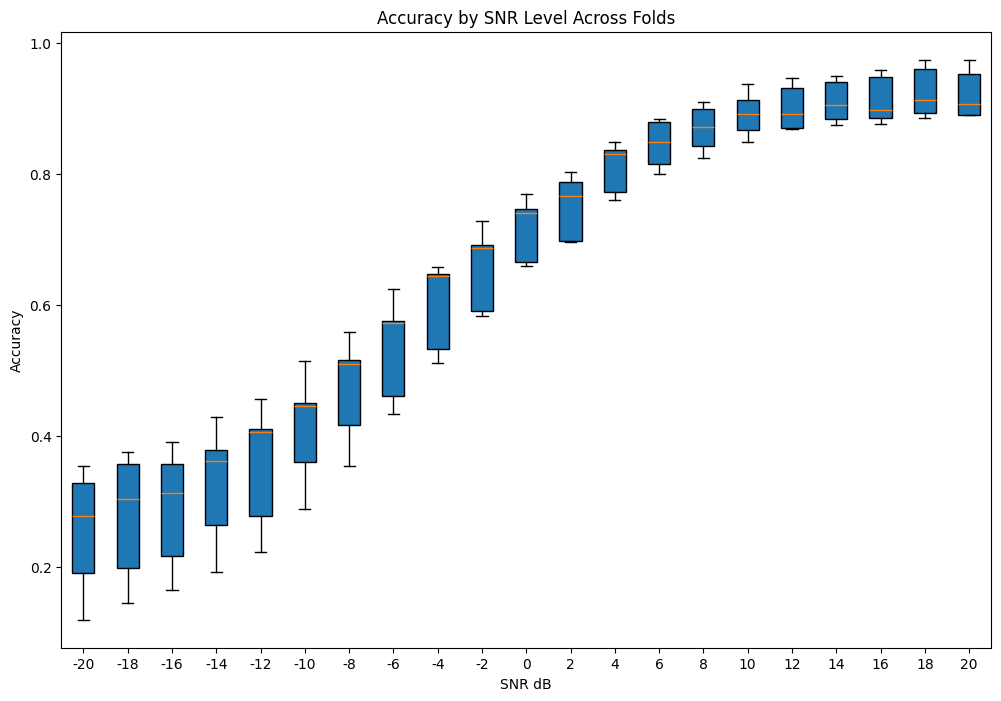

In [15]:
# Load accuracy data from the CSV file
df = pd.read_csv('./snr_accuracies_2022_w_denoiser_snrpred_latest.csv')

# Group by SNR and collect all Accuracy values into lists
snr_accuracies = df.groupby('SNR')['Accuracy'].apply(list).to_dict()

# Create a box plot of accuracy distributions across folds for each SNR
plt.figure(figsize=(12, 8))

# Gather accuracy lists in ascending order of SNR
accuracy_lists = [snr_accuracies[snr] for snr in sorted(snr_accuracies)]

# Plot the boxplot
plt.boxplot(accuracy_lists, patch_artist=True)
plt.title('Accuracy by SNR Level Across Folds')
plt.xlabel('SNR dB')
plt.ylabel('Accuracy')

# Set x-tick labels to the sorted SNR values
plt.xticks(range(1, len(snr_accuracies) + 1), sorted(snr_accuracies.keys()))

# Show the figure
plt.show()


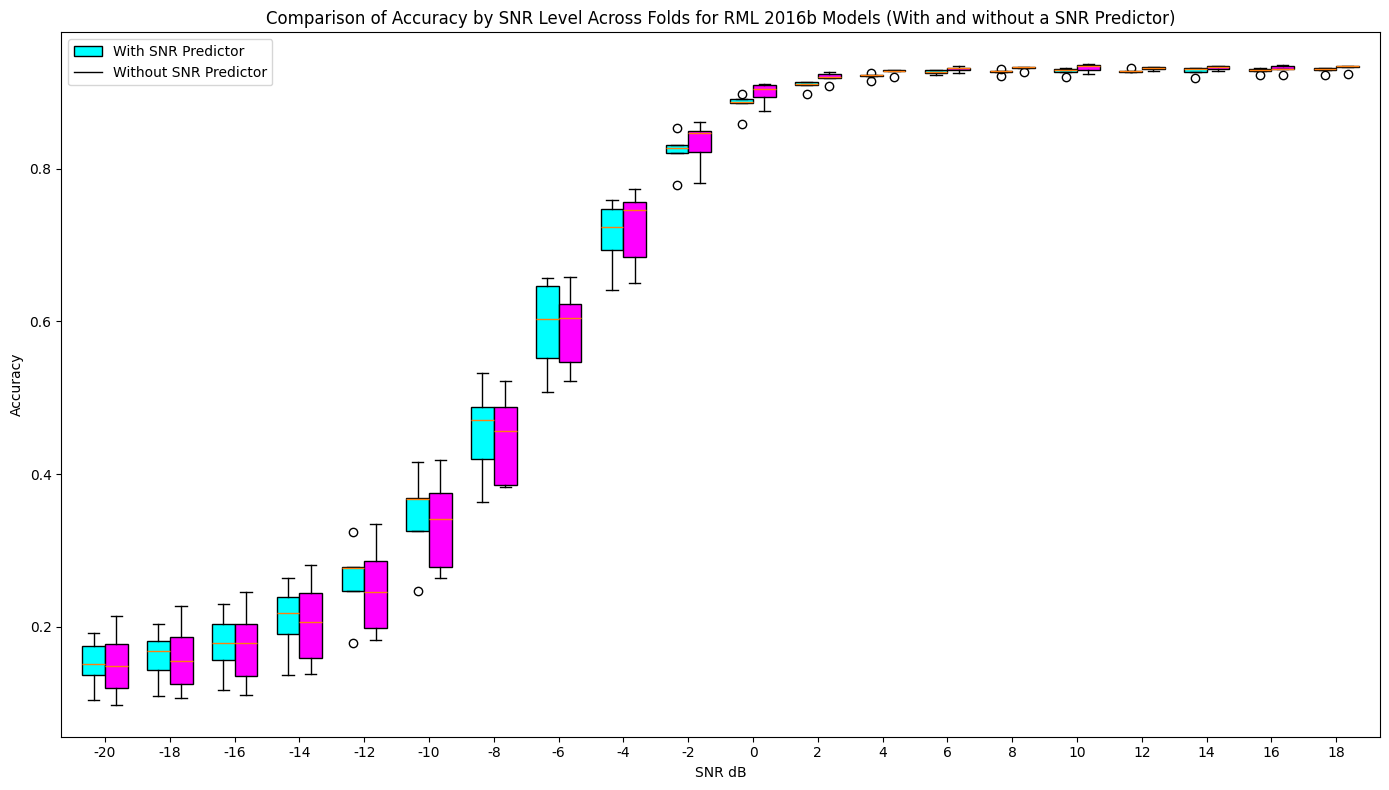

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the data from CSV files
df_model1 = pd.read_csv('./snr_accuracies_2016b_w_denoiser_snrpred_latest.csv')
df_model2 = pd.read_csv('./snr_accuracies_2016_10b_w_denoiser_1.csv')

# Group by SNR and collect accuracies into lists for each model
snr_accuracies_model1 = df_model1.groupby('SNR')['Accuracy'].apply(list).to_dict()
snr_accuracies_model2 = df_model2.groupby('SNR')['Accuracy'].apply(list).to_dict()

# Get the sorted unique SNRs from both datasets (assuming they are the same or overlapping)
sorted_snrs = sorted(set(df_model1['SNR']).union(df_model2['SNR']))

# Create lists of accuracies for each SNR to be used in side-by-side boxplots
accuracies_model1 = [snr_accuracies_model1.get(snr, [np.nan]) for snr in sorted_snrs]
accuracies_model2 = [snr_accuracies_model2.get(snr, [np.nan]) for snr in sorted_snrs]

# Plot configurations
plt.figure(figsize=(14, 8))
box_width = 0.35
index = np.arange(len(sorted_snrs))

# Box plot for Model 1
plt.boxplot(
    accuracies_model1,
    positions=index - box_width/2,
    widths=box_width,
    patch_artist=True,
    boxprops=dict(facecolor="cyan"),
    labels=sorted_snrs
)

# Box plot for Model 2
plt.boxplot(
    accuracies_model2,
    positions=index + box_width/2,
    widths=box_width,
    patch_artist=True,
    boxprops=dict(facecolor="magenta"),
    labels=sorted_snrs
)

# Chart details
plt.title('Comparison of Accuracy by SNR Level Across Folds for RML 2016b Models (With and without a SNR Predictor)')
plt.xlabel('SNR dB')
plt.ylabel('Accuracy')

# Customize the x-ticks to show SNR values
plt.xticks(index, sorted_snrs)

# Add legend
plt.legend(['With SNR Predictor', 'Without SNR Predictor'], loc='upper left')

plt.tight_layout()
plt.show()


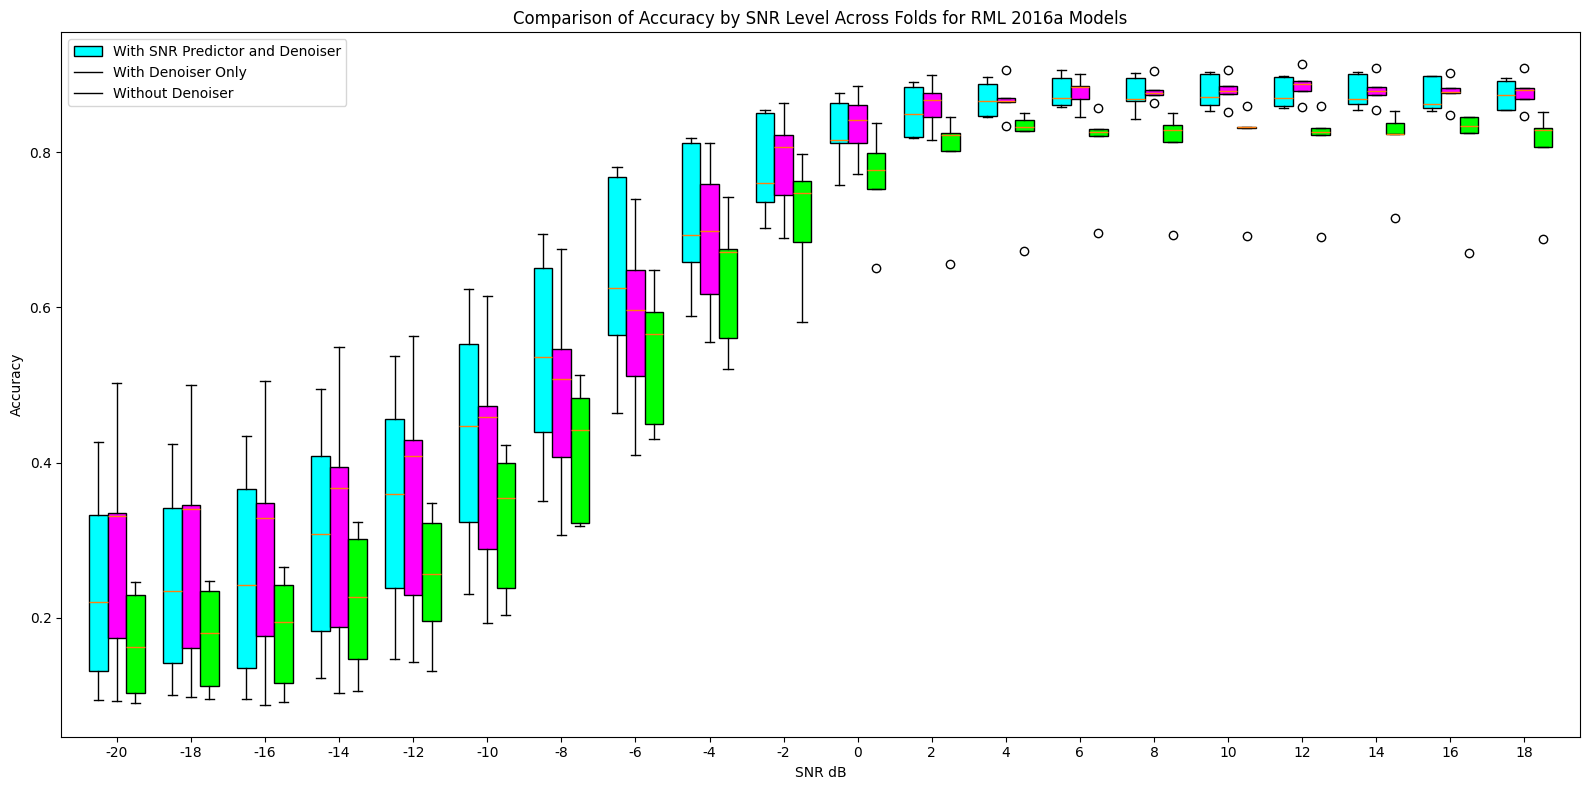

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the data from CSV files
df_model1 = pd.read_csv('./snr_accuracies_2016a_w_denoiser_snrpred_latest.csv')
df_model2 = pd.read_csv('./snr_accuracies_2016_10a_w_denoiser_1.csv')
df_model3 = pd.read_csv('./snr_accuracies_2016_10a_wo_denoiser.csv')  # For the model without denoiser

# Group by SNR and collect accuracies into lists for each model
snr_accuracies_model1 = df_model1.groupby('SNR')['Accuracy'].apply(list).to_dict()
snr_accuracies_model2 = df_model2.groupby('SNR')['Accuracy'].apply(list).to_dict()
snr_accuracies_model3 = df_model3.groupby('SNR')['Accuracy'].apply(list).to_dict()

# Get the sorted unique SNRs from all datasets
sorted_snrs = sorted(set(df_model1['SNR']).union(df_model2['SNR']).union(df_model3['SNR']))

# Create lists of accuracies for each SNR for plotting
accuracies_model1 = [snr_accuracies_model1.get(snr, [np.nan]) for snr in sorted_snrs]
accuracies_model2 = [snr_accuracies_model2.get(snr, [np.nan]) for snr in sorted_snrs]
accuracies_model3 = [snr_accuracies_model3.get(snr, [np.nan]) for snr in sorted_snrs]

# Plot configurations
plt.figure(figsize=(16, 8))  # Increased figure size for clarity
box_width = 0.25             # Adjusted width to accommodate 3 models
index = np.arange(len(sorted_snrs))

# Box plot for Model 1 (With SNR Predictor and Denoiser)
plt.boxplot(
    accuracies_model1,
    positions=index - box_width,
    widths=box_width,
    patch_artist=True,
    boxprops=dict(facecolor="cyan"),
    labels=sorted_snrs
)

# Box plot for Model 2 (With Denoiser only)
plt.boxplot(
    accuracies_model2,
    positions=index,
    widths=box_width,
    patch_artist=True,
    boxprops=dict(facecolor="magenta")
)

# Box plot for Model 3 (Without Denoiser)
plt.boxplot(
    accuracies_model3,
    positions=index + box_width,
    widths=box_width,
    patch_artist=True,
    boxprops=dict(facecolor="lime")
)

# Chart details
plt.title('Comparison of Accuracy by SNR Level Across Folds for RML 2016a Models')
plt.xlabel('SNR dB')
plt.ylabel('Accuracy')
plt.xticks(index, sorted_snrs)

# Add legend
plt.legend(
    ['With SNR Predictor and Denoiser', 'With Denoiser Only', 'Without Denoiser'],
    loc='upper left'
)

plt.tight_layout()
plt.show()


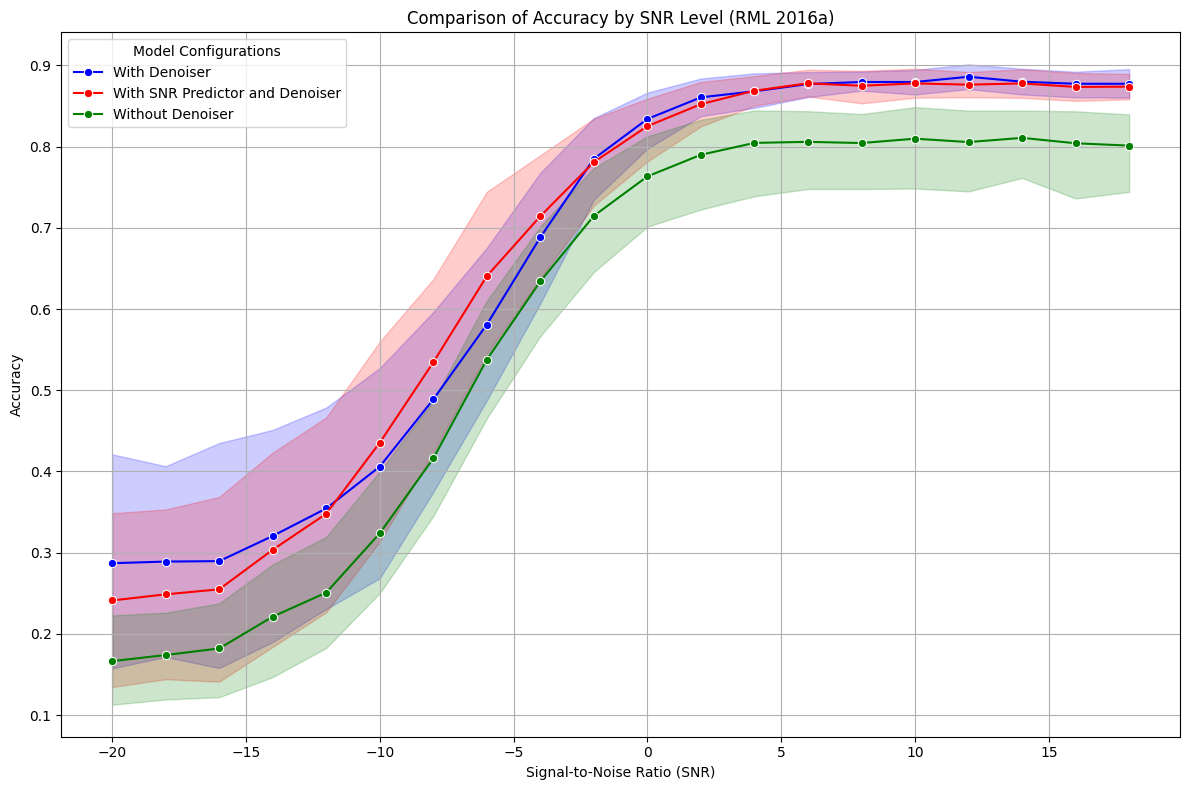

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data from CSV files
data_with_denoiser = pd.read_csv('./snr_accuracies_2016_10a_w_denoiser_1.csv')
data_with_denoiser_and_snr_predictor = pd.read_csv('./snr_accuracies_2016a_w_denoiser_snrpred_latest.csv')
data_without_denoiser = pd.read_csv('./snr_accuracies_2016_10a_wo_denoiser.csv')

# Sort each DataFrame by SNR (optional, but keeps plots organized)
data_with_denoiser = data_with_denoiser.sort_values('SNR')
data_with_denoiser_and_snr_predictor = data_with_denoiser_and_snr_predictor.sort_values('SNR')
data_without_denoiser = data_without_denoiser.sort_values('SNR')

# Set up the matplotlib figure
plt.figure(figsize=(12, 8))

# Plot for "With Denoiser"
sns.lineplot(
    data=data_with_denoiser,
    x='SNR',
    y='Accuracy',
    marker='o',
    color='b',
    label='With Denoiser'
)

# Plot for "With Denoiser and SNR Predictor"
sns.lineplot(
    data=data_with_denoiser_and_snr_predictor,
    x='SNR',
    y='Accuracy',
    marker='o',
    color='r',
    label='With SNR Predictor and Denoiser'
)

# Plot for "Without Denoiser"
sns.lineplot(
    data=data_without_denoiser,
    x='SNR',
    y='Accuracy',
    marker='o',
    color='g',
    label='Without Denoiser'
)

# Chart details
plt.title('Comparison of Accuracy by SNR Level (RML 2016a)')
plt.xlabel('Signal-to-Noise Ratio (SNR)')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend(title='Model Configurations')

plt.tight_layout()
plt.show()


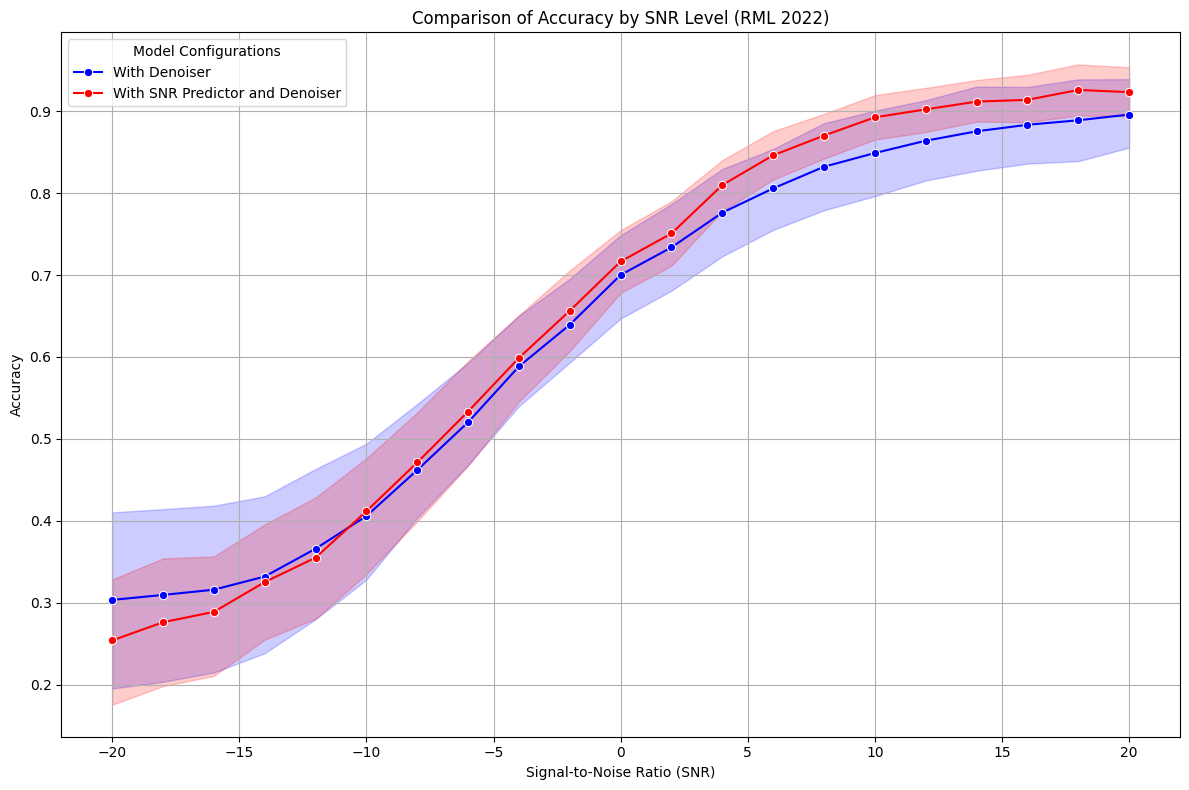

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data from CSV files
data_with_denoiser = pd.read_csv('./snr_accuracies_2022_w_denoiser_1.csv')
data_with_denoiser_and_snr_predictor = pd.read_csv('./snr_accuracies_2022_w_denoiser_snrpred_latest.csv')

# Sort each DataFrame by SNR
data_with_denoiser = data_with_denoiser.sort_values('SNR')
data_with_denoiser_and_snr_predictor = data_with_denoiser_and_snr_predictor.sort_values('SNR')

# Set up the matplotlib figure
plt.figure(figsize=(12, 8))

# Line plot for "With Denoiser"
sns.lineplot(
    data=data_with_denoiser,
    x='SNR',
    y='Accuracy',
    marker='o',
    color='b',
    label='With Denoiser'
)

# Line plot for "With SNR Predictor and Denoiser"
sns.lineplot(
    data=data_with_denoiser_and_snr_predictor,
    x='SNR',
    y='Accuracy',
    marker='o',
    color='r',
    label='With SNR Predictor and Denoiser'
)

# Chart details
plt.title('Comparison of Accuracy by SNR Level (RML 2022)')
plt.xlabel('Signal-to-Noise Ratio (SNR)')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend(title='Model Configurations')

plt.tight_layout()
plt.show()
